# Modern Transformer Tuner on Synthetic Time Series

This notebook builds synthetic signals with controlled structure and runs `ModernTransformerTuner` to recommend patch length, stride, multiscale usage, hierarchical patching, decomposition paths, and attention mode.

In [2]:
import json
import os
import sys

import matplotlib.pyplot as plt
import numpy as np

notebook_dir = os.getcwd()
repo_root = os.path.abspath(os.path.join(notebook_dir, ".."))
if repo_root not in sys.path:
    sys.path.append(repo_root)

from foreblocks import ModernTransformerTuner

np.random.seed(7)
tuner = ModernTransformerTuner()

In [9]:
def make_single_scale_series(length: int = 384) -> np.ndarray:
    t = np.arange(length, dtype=np.float64)
    trend = 0.0025 * t
    daily_cycle = 1.1 * np.sin(2 * np.pi * t / 24.0)
    noise = 0.12 * np.random.randn(length)
    return trend + daily_cycle + noise


def make_multiscale_series(length: int = 512) -> np.ndarray:
    t = np.arange(length, dtype=np.float64)
    short_cycle = 0.45 * np.sin(2 * np.pi * t / 8.0)
    medium_cycle = 0.9 * np.sin(2 * np.pi * t / 48.0 + 0.3)
    long_cycle = 1.3 * np.sin(2 * np.pi * t / 96.0 - 0.2)
    slow_trend = 0.35 * np.sin(2 * np.pi * t / 220.0) + 0.0015 * t
    bursts = 0.16 * np.sign(np.sin(2 * np.pi * t / 32.0))
    noise = 0.14 * np.random.randn(length)
    return short_cycle + medium_cycle + long_cycle + slow_trend + bursts + noise


def summarize_report(report):
    data = report.model_dump()
    summary = {
        "available": data["available"],
        "series_length": data["series_length"],
        "patching": {
            "label": data["patching_label"],
            "score": data["patching_score"],
            "patch_len": data["recommended_patch_len"],
            "stride": data["recommended_patch_stride"],
            "patch_set": data["recommended_patch_set"],
            "num_patches": data["estimated_num_patches"],
        },
        "dominant_period": data["dominant_period"],
        "multiscale": {
            "label": data["multiscale_label"],
            "score": data["multiscale_score"],
        },
        "hierarchical": {
            "label": data["hierarchical_label"],
            "score": data["hierarchical_score"],
            "periods": data["recommended_hierarchical_periods"],
        },
        "attention_mode": data["recommended_attention_mode"],
        "preprocessing_heads": data["recommended_preprocessing_heads"],
        "decompositions": data["recommended_decompositions"],
        "model_kwargs": data["recommended_model_kwargs"],
        "notes": data["notes"],
    }
    print(json.dumps(summary, indent=2))

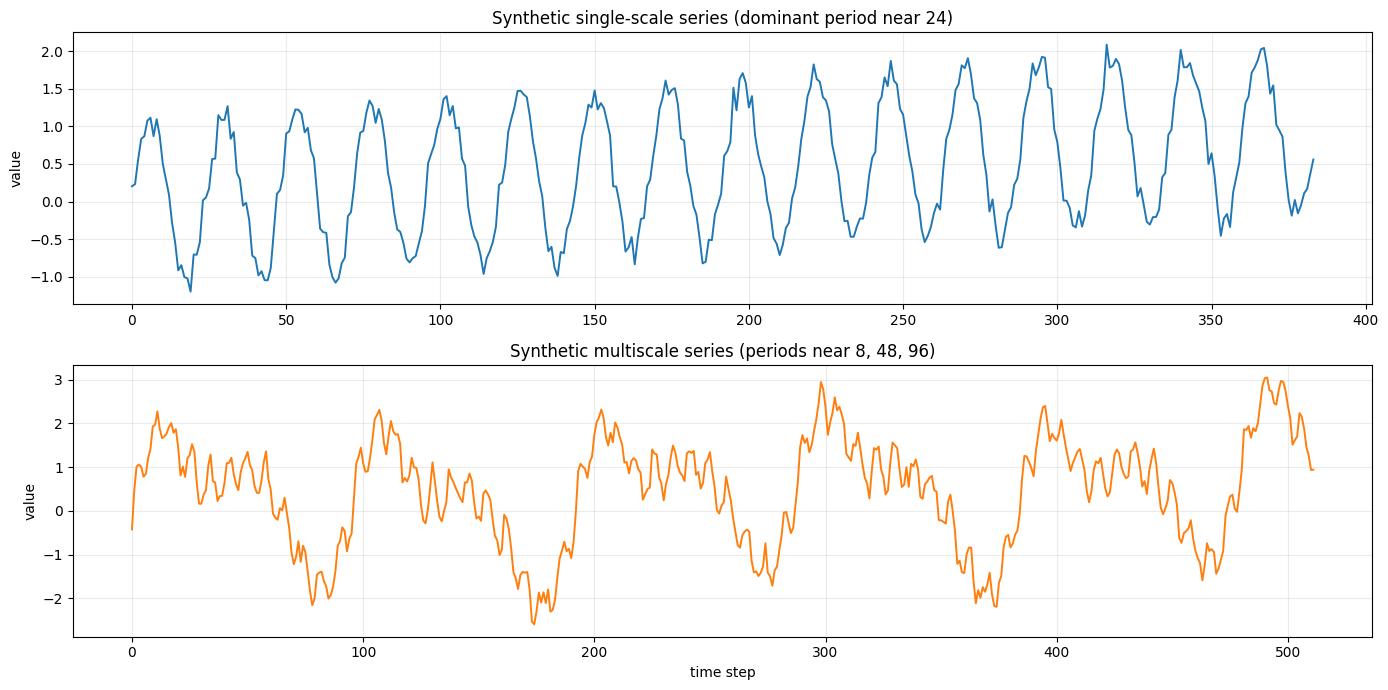

In [4]:
single_scale = make_single_scale_series()
multi_scale = make_multiscale_series()

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)
axes[0].plot(single_scale, color="tab:blue", linewidth=1.4)
axes[0].set_title("Synthetic single-scale series (dominant period near 24)")
axes[0].set_ylabel("value")
axes[0].grid(alpha=0.25)

axes[1].plot(multi_scale, color="tab:orange", linewidth=1.4)
axes[1].set_title("Synthetic multiscale series (periods near 8, 48, 96)")
axes[1].set_xlabel("time step")
axes[1].set_ylabel("value")
axes[1].grid(alpha=0.25)

plt.tight_layout()

## Analyze a clean seasonal signal

This series has a strong main period and only light noise, so the tuner should usually favor a single main patch scale and avoid aggressive multiscale recommendations.

In [10]:
single_report = tuner.analyze(single_scale)
summarize_report(single_report)

{
  "available": true,
  "series_length": 384,
  "patching": {
    "label": "good",
    "score": 94,
    "patch_len": 8,
    "stride": 8,
    "patch_set": [
      4,
      8,
      24
    ],
    "num_patches": 48
  },
  "dominant_period": 24.0,
  "multiscale": {
    "label": "moderate",
    "score": 58
  },
  "hierarchical": {
    "label": "high",
    "score": 83,
    "periods": [
      23,
      48,
      72,
      24
    ]
  },
  "attention_mode": "standard",
  "preprocessing_heads": [
    "RevINHead",
    "DecompositionBlock",
    "MultiScaleConvHead"
  ],
  "decompositions": [
    {
      "method": "mstl",
      "suitability": "moderate",
      "rationale": "Multiple seasonal components detected.",
      "periods": [
        23,
        24,
        26
      ]
    }
  ],
  "model_kwargs": {
    "patch_encoder": true,
    "patch_decoder": false,
    "patch_len": 8,
    "patch_stride": 8,
    "attention_mode": "standard",
    "recommended_patch_set": [
      4,
      8,
      24
    ]

## Analyze a multiscale signal

This second signal mixes fast, medium, and long rhythms, so the tuner should push toward multiscale or hierarchical patching and may recommend decomposition blocks.

In [6]:
multi_report = tuner.analyze(multi_scale, seasonal_periods=[8, 48, 96])
summarize_report(multi_report)

{
  "available": true,
  "series_length": 512,
  "patching": {
    "label": "good",
    "score": 95,
    "patch_len": 32,
    "stride": 8,
    "patch_set": [
      16,
      32,
      64
    ],
    "num_patches": 61
  },
  "dominant_period": 102.0,
  "multiscale": {
    "label": "moderate",
    "score": 51
  },
  "hierarchical": {
    "label": "high",
    "score": 83,
    "periods": [
      6,
      47,
      48,
      85
    ]
  },
  "attention_mode": "standard",
  "preprocessing_heads": [
    "RevINHead",
    "DecompositionBlock",
    "MultiScaleConvHead"
  ],
  "decompositions": [
    {
      "method": "mstl",
      "suitability": "moderate",
      "rationale": "Multiple seasonal components detected.",
      "periods": [
        6,
        8,
        47
      ]
    }
  ],
  "model_kwargs": {
    "patch_encoder": true,
    "patch_decoder": false,
    "patch_len": 32,
    "patch_stride": 8,
    "attention_mode": "standard",
    "recommended_patch_set": [
      16,
      32,
      64
 

In [7]:
comparison = {
    "single_scale": {
        "patch_len": single_report.recommended_patch_len,
        "patch_stride": single_report.recommended_patch_stride,
        "multiscale": single_report.multiscale_label,
        "hierarchical": single_report.hierarchical_label,
        "attention": single_report.recommended_attention_mode,
    },
    "multi_scale": {
        "patch_len": multi_report.recommended_patch_len,
        "patch_stride": multi_report.recommended_patch_stride,
        "multiscale": multi_report.multiscale_label,
        "hierarchical": multi_report.hierarchical_label,
        "attention": multi_report.recommended_attention_mode,
    },
}
print(json.dumps(comparison, indent=2))

{
  "single_scale": {
    "patch_len": 8,
    "patch_stride": 8,
    "multiscale": "moderate",
    "hierarchical": "high",
    "attention": "standard"
  },
  "multi_scale": {
    "patch_len": 32,
    "patch_stride": 8,
    "multiscale": "moderate",
    "hierarchical": "high",
    "attention": "standard"
  }
}


## Lift the recommendation into model kwargs

The tuner already returns a minimal configuration payload that can be merged into your transformer settings before model construction.

In [8]:
base_model_kwargs = {
    "hidden_size": 128,
    "nhead": 8,
    "num_encoder_layers": 2,
    "num_decoder_layers": 1,
    "dim_feedforward": 256,
    "dropout": 0.1,
}

recommended_model_kwargs = {
    **base_model_kwargs,
    **multi_report.recommended_model_kwargs,
}

print(json.dumps(recommended_model_kwargs, indent=2))

{
  "hidden_size": 128,
  "nhead": 8,
  "num_encoder_layers": 2,
  "num_decoder_layers": 1,
  "dim_feedforward": 256,
  "dropout": 0.1,
  "patch_encoder": true,
  "patch_decoder": false,
  "patch_len": 32,
  "patch_stride": 8,
  "attention_mode": "standard",
  "recommended_patch_set": [
    16,
    32,
    64
  ],
  "use_multiscale": true,
  "use_hierarchical": true,
  "context_length": null,
  "estimated_num_patches": 61
}
